# LR control and SNN seed

logistic-regression reference attack sets the disclosure
target and proves the leakage is exploitable. Then, we map that linear
readout onto the SNN and
export a seed the C engine can refine.


In [ ]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

import sca

H5_PATH  = "../modulated_dataset/aes_hd_snn_ready.h5"
PLOT_DIR = "../modulated_dataset/plots/validation"
SEED_BASENAME = "evaluate-network-csvs/best_network"
os.makedirs(PLOT_DIR, exist_ok=True)

X_prof, y_prof, _, _ = sca.load_h5(H5_PATH, "Profiling_traces")
X_atk,  y_atk, ct_atk, meta = sca.load_h5(H5_PATH, "Attack_traces")
ct_hi, ct_lo, true_k = meta

## LR reference

Balanced weighting flattens the binomial prior so the posteriors approximate
per-class likelihoods, which is what the key distinguisher needs.


In [12]:
lr = LogisticRegression(max_iter=2000, C=0.1, class_weight="balanced").fit(X_prof, y_prof)

lr_logp = lr.predict_log_proba(X_atk)
lr_rank, lr_rec, lr_ge, lr_axis, lr_disc = sca.guessing_entropy(lr_logp, ct_atk, meta)
print(f"recovered {lr_rec} (true {true_k}), rank {lr_rank}, disclosure {lr_disc}")

recovered 166 (true 166), rank 0, disclosure 1017


In [13]:
# coef/intercept indexed by HD class -> output node
coef = np.zeros((sca.NUM_OUTPUTS, sca.NUM_INPUTS))
intercept = np.zeros(sca.NUM_OUTPUTS)
for i, c in enumerate(lr.classes_):
    coef[int(c)] = lr.coef_[i]
    intercept[int(c)] = lr.intercept_[i]

## Mapping LR onto the neuron

`drive = weight * input`, so a synapse weight is `round(K * coef)` clamped to
int8. `K` sets the operating point.

The engine selects on class-balanced mean log-likelihood. A seed
must beat the uniform baseline ln(1/9) = -2.197 (11% percent, random guessing of the HW) or it gets culled in the first
generation, so the sweep scores each candidate by that fitness.


In [14]:
def build_seed(K, thr_base, use_bias):
    thr = np.full(sca.NUM_OUTPUTS, thr_base, np.int64)
    if use_bias:
        thr = np.clip(np.round(thr_base - 7.0 * K * intercept), 2, 1000).astype(np.int64)
    W = np.clip(np.round(K * coef), -127, 127).astype(np.int64)
    src, tgt, w = [], [], []
    for o in range(sca.NUM_OUTPUTS):
        for p in range(sca.NUM_INPUTS):
            if W[o, p]:
                src.append(p); tgt.append(sca.NUM_INPUTS + o); w.append(int(W[o, p]))
    return thr, np.array(src), np.array(tgt), np.array(w)

def seed_net(thr, src, tgt, w):
    is_in = src < sca.NUM_INPUTS
    return {
        "num_lif": sca.NUM_OUTPUTS, "num_hidden": 0, "num_synapses": len(w),
        "threshold": thr[:, None],
        "leak": np.full((sca.NUM_OUTPUTS, 1), 3), "reset": np.full((sca.NUM_OUTPUTS, 1), -5),
        "resting": np.zeros((sca.NUM_OUTPUTS, 1), np.int64), "refrac_p": np.full((sca.NUM_OUTPUTS, 1), 2),
        "in_src": src[is_in], "in_tgt": tgt[is_in] - sca.NUM_INPUTS, "in_w": w[is_in],
        "nn_src": np.array([], np.int64), "nn_tgt": np.array([], np.int64), "nn_w": np.array([], np.int64),
    }

def fitness(counts, labels, n_syn):
    p = (counts + sca.ALPHA) / (counts.sum(1, keepdims=True) + sca.NUM_OUTPUTS * sca.ALPHA)
    ll = np.log(p[np.arange(len(labels)), labels] + 1e-9)
    per_class = [ll[labels == c].mean() for c in range(sca.NUM_OUTPUTS) if (labels == c).any()]
    return float(np.mean(per_class) - 1e-7 * (n_syn + sca.NUM_OUTPUTS))

In [15]:
sigma = float((X_atk @ coef.T).std(0).mean())
K_grid = sorted({t / sigma for t in (0.5, 1, 2, 4, 8, 16)})
UNIFORM = np.log(1 / sca.NUM_OUTPUTS)

rng = np.random.default_rng(0)
sub = rng.choice(len(X_atk), 3000, replace=False)
psub = np.concatenate([rng.choice(np.where(y_prof == c)[0], min(250, int((y_prof == c).sum())), replace=False)
                       for c in range(sca.NUM_OUTPUTS)])

print(f"{'K':>8}{'thr':>5}{'bias':>6}{'spk':>7}{'dead':>5}{'rank':>6}{'fit':>9}")
best = None
for K in K_grid:
    for thr_base in (6, 12, 20):
        for use_bias in (False, True):
            thr, src, tgt, w = build_seed(K, thr_base, use_bias)
            if not len(w):
                continue
            net = seed_net(thr, src, tgt, w)
            ca = sca.spike_counts(net, X_atk[sub])
            dead = int((ca.sum(0) == 0).sum())
            rank, *_ = sca.guessing_entropy(sca.log_proba(ca), ct_atk[sub], meta, n_axis=20, n_avg=10)
            fit = fitness(sca.spike_counts(net, X_prof[psub]), y_prof[psub], len(w))
            print(f"{K:>8.2f}{thr_base:>5}{str(use_bias):>6}{ca.sum(1).mean():>7.1f}{dead:>5}{rank:>6}{fit:>9.4f}")
            survives = fit > UNIFORM and dead == 0
            key = (0 if survives else 1, -fit, rank)
            if best is None or key < best[0]:
                best = (key, (K, thr_base, use_bias, fit, survives))

       K  thr  bias    spk dead  rank      fit
    1.84    6 False    1.6    7   201  -2.1919
    1.84    6  True    1.4    7   201  -2.1917
    1.84   12 False    1.0    7   201  -2.1915
    1.84   12  True    0.9    7   201  -2.1917
    1.84   20 False    0.2    7    87  -2.1929
    1.84   20  True    0.1    7    38  -2.1946
    3.68    6 False    7.9    3     4  -2.1858
    3.68    6  True    6.9    3     5  -2.1856
    3.68   12 False    5.3    3     2  -2.1835
    3.68   12  True    4.3    3     4  -2.1861
    3.68   20 False    2.0    4     4  -2.1891
    3.68   20  True    1.3    4    10  -2.1900
    7.35    6 False   16.2    0     1  -2.1918
    7.35    6  True   14.7    0     1  -2.1927
    7.35   12 False   11.1    0     1  -2.1829
    7.35   12  True    9.6    0     1  -2.1846
    7.35   20 False    4.7    1    13  -2.1816
    7.35   20  True    3.2    1    39  -2.1876
   14.70    6 False   39.3    0     0  -2.1958
   14.70    6  True   38.8    0     0  -2.1939
   14.70   12

In [16]:
K, thr_base, use_bias, fit, survives = best[1]
print(f"best: K={K:.2f} thr={thr_base} bias={use_bias} fit={fit:.4f} survives={survives}")

best: K=14.70 thr=20 bias=False fit=-2.1743 survives=True


## evaluation and export



In [17]:
thr, src, tgt, w = build_seed(K, thr_base, use_bias)
net = seed_net(thr, src, tgt, w)

counts = sca.spike_counts(net, X_atk)
s_rank, s_rec, s_ge, s_axis, s_disc = sca.guessing_entropy(sca.log_proba(counts), ct_atk, meta)
gen0 = fitness(sca.spike_counts(net, X_prof), y_prof, len(w))

print(f"synapses {len(w)} | spikes/trace {counts.sum(1).mean():.1f} | dead {(counts.sum(0)==0).sum()}")
print(f"recovered {s_rec} (true {true_k}), rank {s_rank}, disclosure {s_disc}  (LR {lr_disc})")
print(f"predicted engine gen-0 fitness: {gen0:.4f}")

synapses 116 | spikes/trace 17.8 | dead 0
recovered 166 (true 166), rank 0, disclosure 3390  (LR 1017)
predicted engine gen-0 fitness: -2.1769


In [18]:
os.makedirs(os.path.dirname(SEED_BASENAME), exist_ok=True)
with open(SEED_BASENAME + "_neurons.csv", "w") as f:
    f.write("node_id,type,threshold,leak_factor,reset_potential,resting_potential,refractory_period\n")
    for o in range(sca.NUM_OUTPUTS):
        f.write(f"{sca.NUM_INPUTS+o},output,{int(thr[o])},3,-5,0,2\n")
with open(SEED_BASENAME + "_synapses.csv", "w") as f:
    f.write("source_node,target_node,weight\n")
    for s, t, ww in zip(src, tgt, w):
        f.write(f"{int(s)},{int(t)},{int(ww)}\n")

rt = sca.spike_counts(sca.load_network(SEED_BASENAME), X_atk)
print("round-trip exact:", bool(np.array_equal(rt, counts)))
print("seed ->", SEED_BASENAME)

round-trip exact: True
seed -> lr-network-csvs/best_network


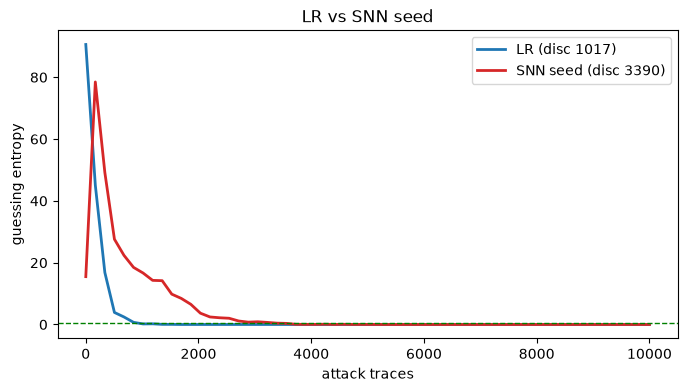

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lr_axis, lr_ge, color="#1f77b4", lw=2, label=f"LR (disc {lr_disc})")
ax.plot(s_axis, s_ge, color="#d62728", lw=2, label=f"SNN seed (disc {s_disc})")
ax.axhline(0.5, color="green", ls="--", lw=1)
ax.set_xlabel("attack traces"); ax.set_ylabel("guessing entropy")
ax.set_title("LR vs SNN seed"); ax.legend()
fig.savefig(os.path.join(PLOT_DIR, "08_seed_vs_lr_ge.png"), dpi=120)
plt.show()